In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from few.waveform import GenerateEMRIWaveform, FastSchwarzschildEccentricFlux, FastKerrEccentricEquatorialFlux


import os
import sys

# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

# Add it to Python path
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike
import modeselector
import dynesty
# import gc
# import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")



In [2]:
import stableemrifisher
stableemrifisher.__file__
from tqdm import tqdm
from stableemrifisher.fisher.fisher import StableEMRIFisher


startup


# Set Up

In [3]:
# GPU configuration
use_gpu = True
dt = 10     # Time step
T = 0.25   # Total time

# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
        "err": 1e-15  # Error tolerance 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": "cuda12x" # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
    "pad_output": True
}

waveform_class = FastKerrEccentricEquatorialFlux
waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                             amplitude_kwargs=amplitude_kwargs,
                             Ylm_kwargs=Ylm_kwargs,
                             sum_kwargs=sum_kwargs,
                             use_gpu=use_gpu)

 
#waveform generator setup
waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(frame='detector')

waveform_gen = GenerateEMRIWaveform(
    waveform_class, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs,
    use_gpu=use_gpu
)

In [4]:
gwf = GWfuncs.GravWaveAnalysis(T, dt)

In [9]:
from lisatools.sensitivity import get_sensitivity, CornishLISASens

sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                      stats_for_nerds = True, use_gpu = use_gpu,
                      deriv_type='stable', noise_model=get_sensitivity, noise_kwargs={'sens_fn':CornishLISASens, 'return_type': 'PSD'}, channels=["A"])


In [5]:
# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 7.5
e0 = 0.4 
# NOTE: BELOW FIXED
xI0 = 1.0
dist = 0.5 # Gpc
# Polar and azimuthal angles .. detector frame
# S = Solar system barycenter
# K = spin angular momentum of the MBH
qS = 0.5 
phiS = 1 
qK = 1 #fixed
phiK = phiS + np.pi/3
# Phases
Phi_phi0 = 0.4
Phi_theta0 = 0.0 # equatorial
Phi_r0 = 0.5


In [11]:
waveform = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,  T=T, dt=dt)

In [12]:
hf = gwf.freq_wave(waveform)
np.sqrt(gwf.inner(hf,hf))

array(107.43946161)

# Computing Fisher 

T:  0.25 dt:  10
Body is not plunging, Fisher should be stable.
wave ndim: 2
Computing SNR for parameters: (1000000.0, 30.0, 0.7, 7.5, 0.4, 1.0, 0.5, 0.5, 1, 1, 2.0471975511965974, 0.4, 0.0, 0.5)
Waveform Generated. SNR: 107.4394616101364
calculating stable deltas...
Gamma_ii for m1: 592.8246153666494
Gamma_ii for m1: 592.8246153555673
Gamma_ii for m1: 592.8246153541139
Gamma_ii for m1: 592.8246154215007
Gamma_ii for m1: 592.8246154226514
Gamma_ii for m1: 592.8246132316539
Gamma_ii for m1: 592.8245937948226
Gamma_ii for m1: 592.8246920518216
[1.8693689444083802e-11, 2.451606252154343e-12, 1.1367061089931033e-10, 1.9411106446681274e-12, 3.695861257105813e-09, 3.278681668055054e-08, 1.6574376925376608e-07]
3


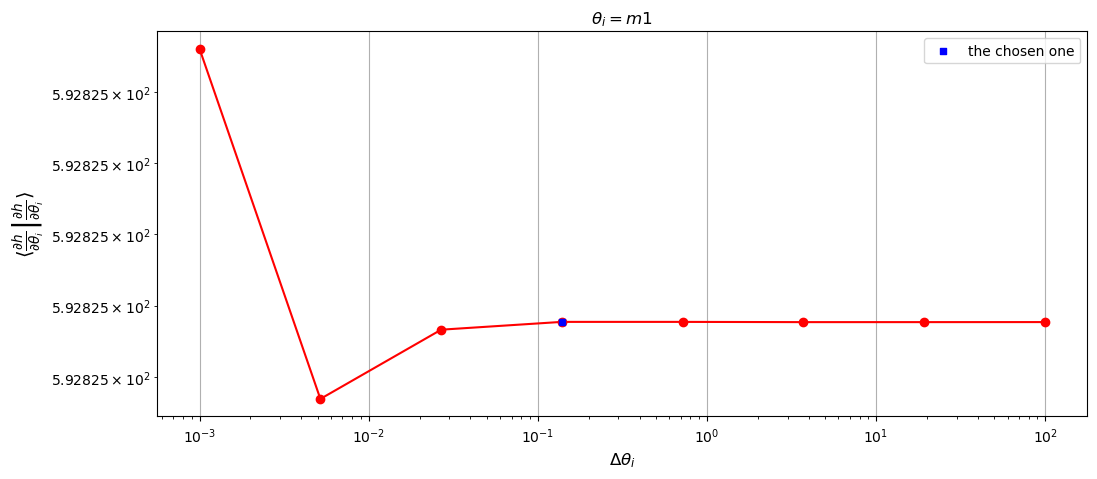

Gamma_ii for m2: 21227273818.435528
Gamma_ii for m2: 21227273818.43465
Gamma_ii for m2: 21227273813.319714
Gamma_ii for m2: 21227273766.620632
Gamma_ii for m2: 21227273899.844357
Gamma_ii for m2: 21227273384.163345
Gamma_ii for m2: 21227266988.09415
Gamma_ii for m2: 21227260563.64509
[4.133269201680511e-14, 2.4096060914820605e-10, 2.1999566187501476e-09, 6.276063756176021e-09, 2.429332311632054e-08, 3.0131383368292764e-07, 3.026508787172594e-07]
0


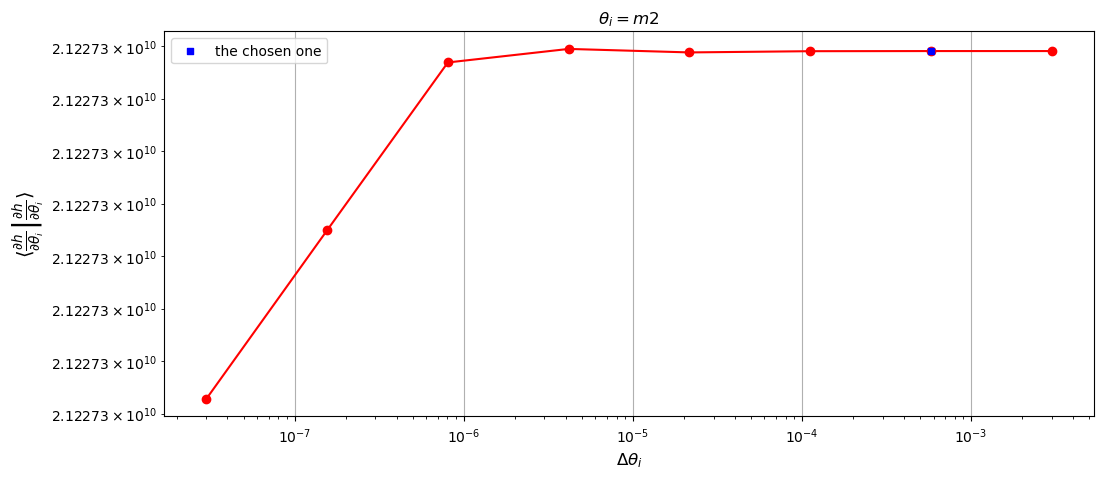

Gamma_ii for a: 23167882053073.094
Gamma_ii for a: 23167889371352.16
Gamma_ii for a: 23167871207049.7
Gamma_ii for a: 23167848060874.188
Gamma_ii for a: 23166655352788.316
Gamma_ii for a: 23166738778375.04
Gamma_ii for a: 23220136117295.93
Gamma_ii for a: 23303158479100.51
[3.158802663938622e-07, 7.840298445465428e-07, 9.99064541985147e-07, 5.1483827410914565e-05, 3.6010932535972545e-06, 0.0022996135186785865, 0.003562708543523867]
0


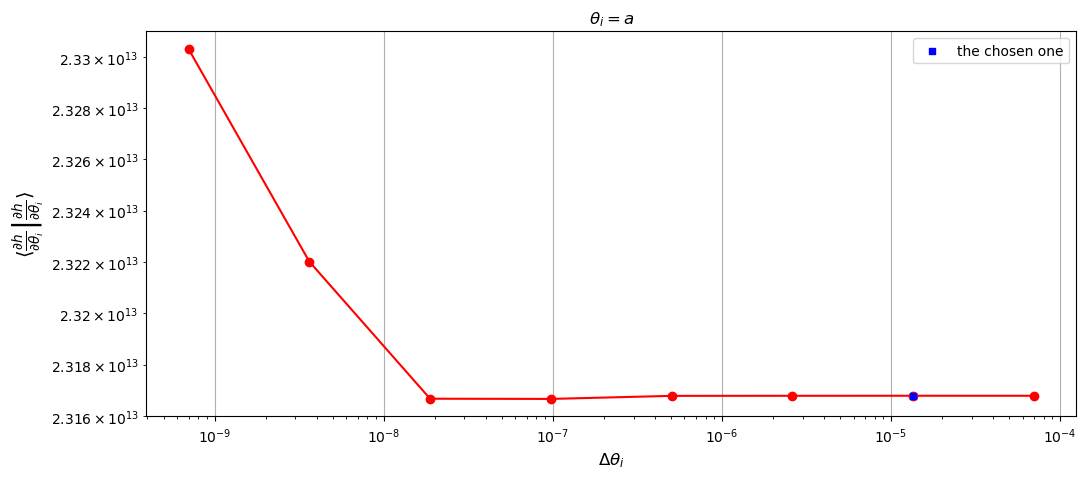

Gamma_ii for p0: 28486664707204.785
Gamma_ii for p0: 28486664571205.395
Gamma_ii for p0: 28486665476399.133
Gamma_ii for p0: 28486677884669.973
Gamma_ii for p0: 28486668891134.305
Gamma_ii for p0: 28486796307117.797
Gamma_ii for p0: 28486561108887.14
Gamma_ii for p0: 28479257143610.965
[4.774142310871647e-09, 3.1776051115255746e-08, 4.355815335884156e-07, 3.157103311144864e-07, 4.472808458996526e-06, 8.25646274947781e-06, 0.00025646614444135363]
0


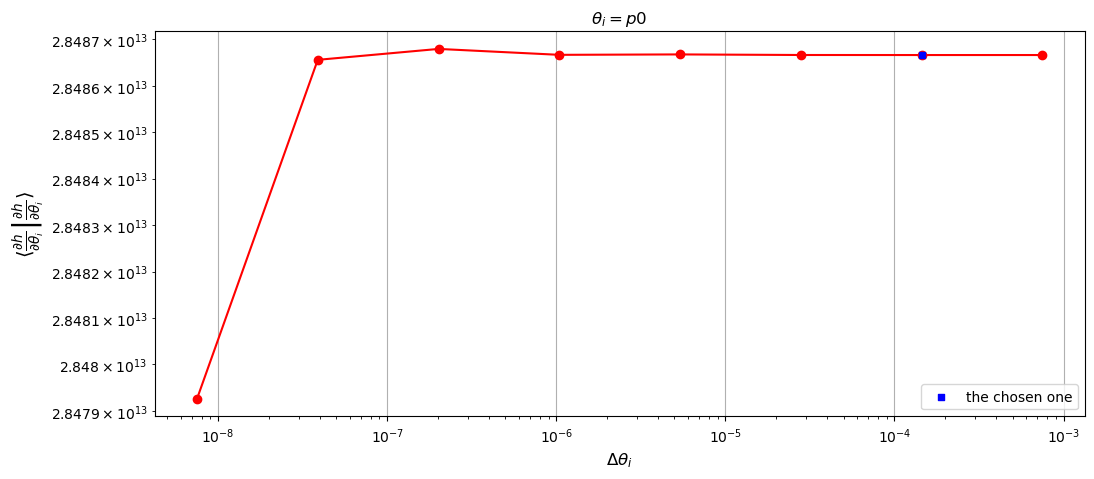

Gamma_ii for e0: 172687134259449.22
Gamma_ii for e0: 172687138288579.03
Gamma_ii for e0: 172687141139206.44
Gamma_ii for e0: 172687166662163.34
Gamma_ii for e0: 172684739885720.5
Gamma_ii for e0: 172699414658532.9
Gamma_ii for e0: 172555707601094.12
Gamma_ii for e0: 172762405421732.94
[2.333196237097221e-08, 1.6507467709781902e-08, 1.477988052012102e-07, 1.4053218856800808e-05, 8.497291575319872e-05, 0.0008328154393536273, 0.0011964282398953597]
1


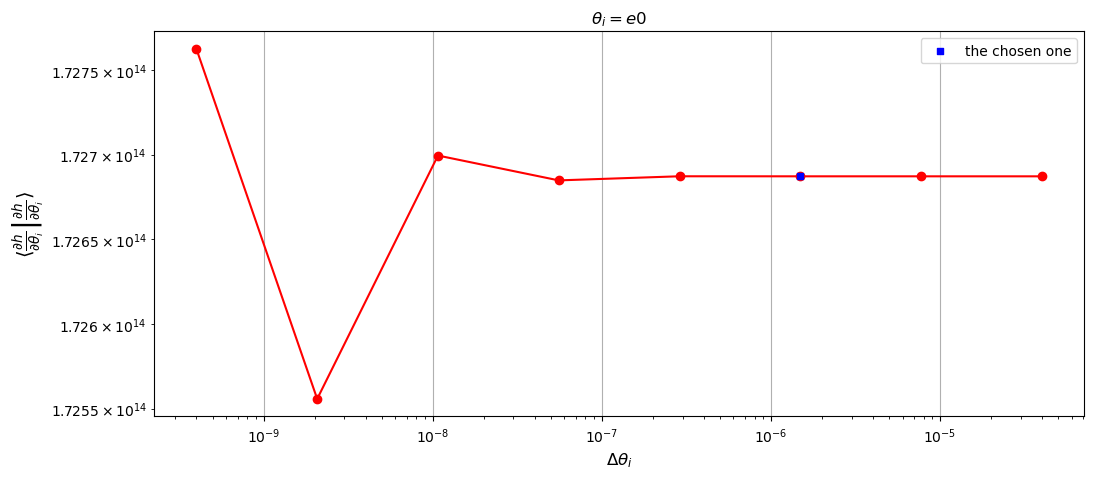

Gamma_ii for qS: 38367.03760832276
Gamma_ii for qS: 38367.04016171832
Gamma_ii for qS: 38367.04016527559
Gamma_ii for qS: 38367.04016528031
Gamma_ii for qS: 38367.040165278995
Gamma_ii for qS: 38367.040165279665
Gamma_ii for qS: 38367.040165376275
Gamma_ii for qS: 38367.040165755105
[6.655179947141703e-08, 9.271673274648665e-11, 1.2307690328111978e-13, 3.4324991515999147e-14, 1.7446957013656722e-14, 2.5180510350733764e-12, 9.87383982458472e-12]
4


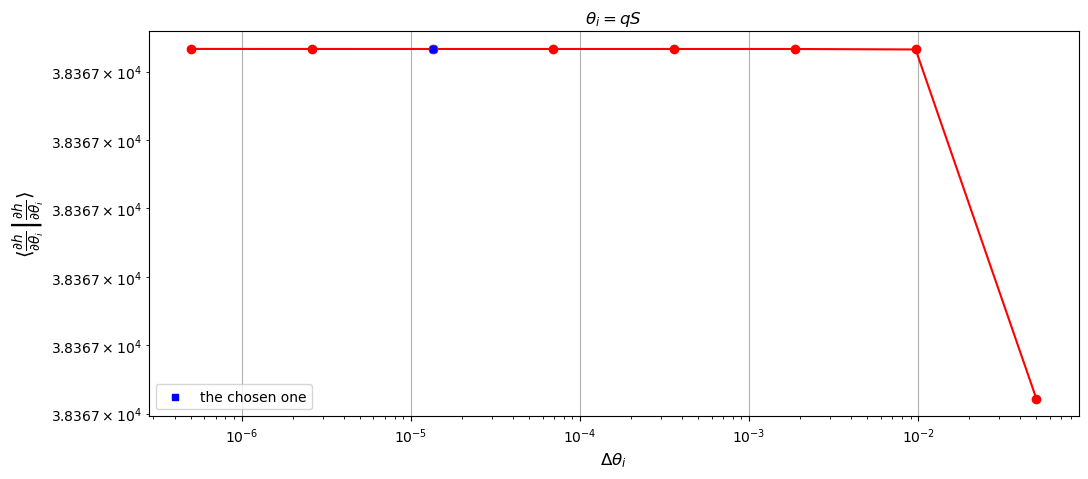

Gamma_ii for phiS: 43009.26185319482
Gamma_ii for phiS: 43009.374694069666
Gamma_ii for phiS: 43009.37485195146
Gamma_ii for phiS: 43009.37485217145
Gamma_ii for phiS: 43009.374852189285
Gamma_ii for phiS: 43009.374852199486
Gamma_ii for phiS: 43009.37485252937
Gamma_ii for phiS: 43009.37485349582
[2.623634397171272e-06, 3.6708693835474926e-09, 5.1148983034736935e-12, 4.146391844487787e-13, 2.371783503047939e-13, 7.67006364078928e-12, 2.2470703219212278e-11]
4


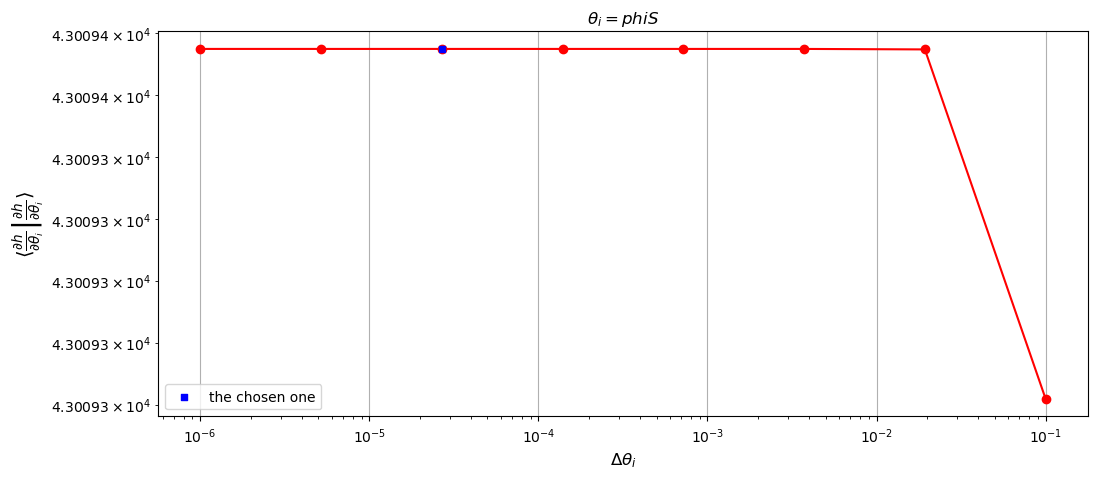

stable deltas: {'m1': 0.13894954943731375, 'm2': 0.0005792093186649751, 'a': 1.351488410218275e-05, 'p0': 0.0001448023296662437, 'e0': 1.4910374881259754e-06, 'dist': 0.0, 'qS': 1.3413478976398634e-05, 'phiS': 2.6826957952797274e-05, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 443.7391633987427 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 64.23416042327881 seconds


In [13]:
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
# NOTE: leaving off xI0 and Phi_theta0 for now as fixed
param_names = ['m1','m2','a','p0','e0','dist','qS','phiS','Phi_phi0','Phi_r0']
der_order = 4
Ndelta = 8
stability_plot = True
# using default delta range first by SEF
Fisher = sef(*pars_list, param_names = param_names, 
             T = T, dt = dt, 
             der_order = der_order, 
             Ndelta = Ndelta, 
             stability_plot = stability_plot,
            #  delta_range = delta_range,
            live_dangerously = False)

In [14]:
np.linalg.eigvals(Fisher)

array([2.16163024e+14, 8.05812363e+12, 1.41763586e+11, 1.08434476e+07,
       4.85299757e+04, 1.35077860e+04, 2.81927598e+03, 2.12700739e-05,
       9.59336662e+02, 3.47983016e+02])

In [15]:
# CHAIN RULE FOR FISHER
J_mx = np.eye(10)
J_mx[0, 0] = m1 * np.log(10) 
J_mx[1, 1] = m2 * np.log(10) 
J_mx[6, 6] = -1/np.sin(qS)

Fisher_scaled = J_mx.T @ Fisher @ J_mx

(<Figure size 2000x2000 with 55 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [

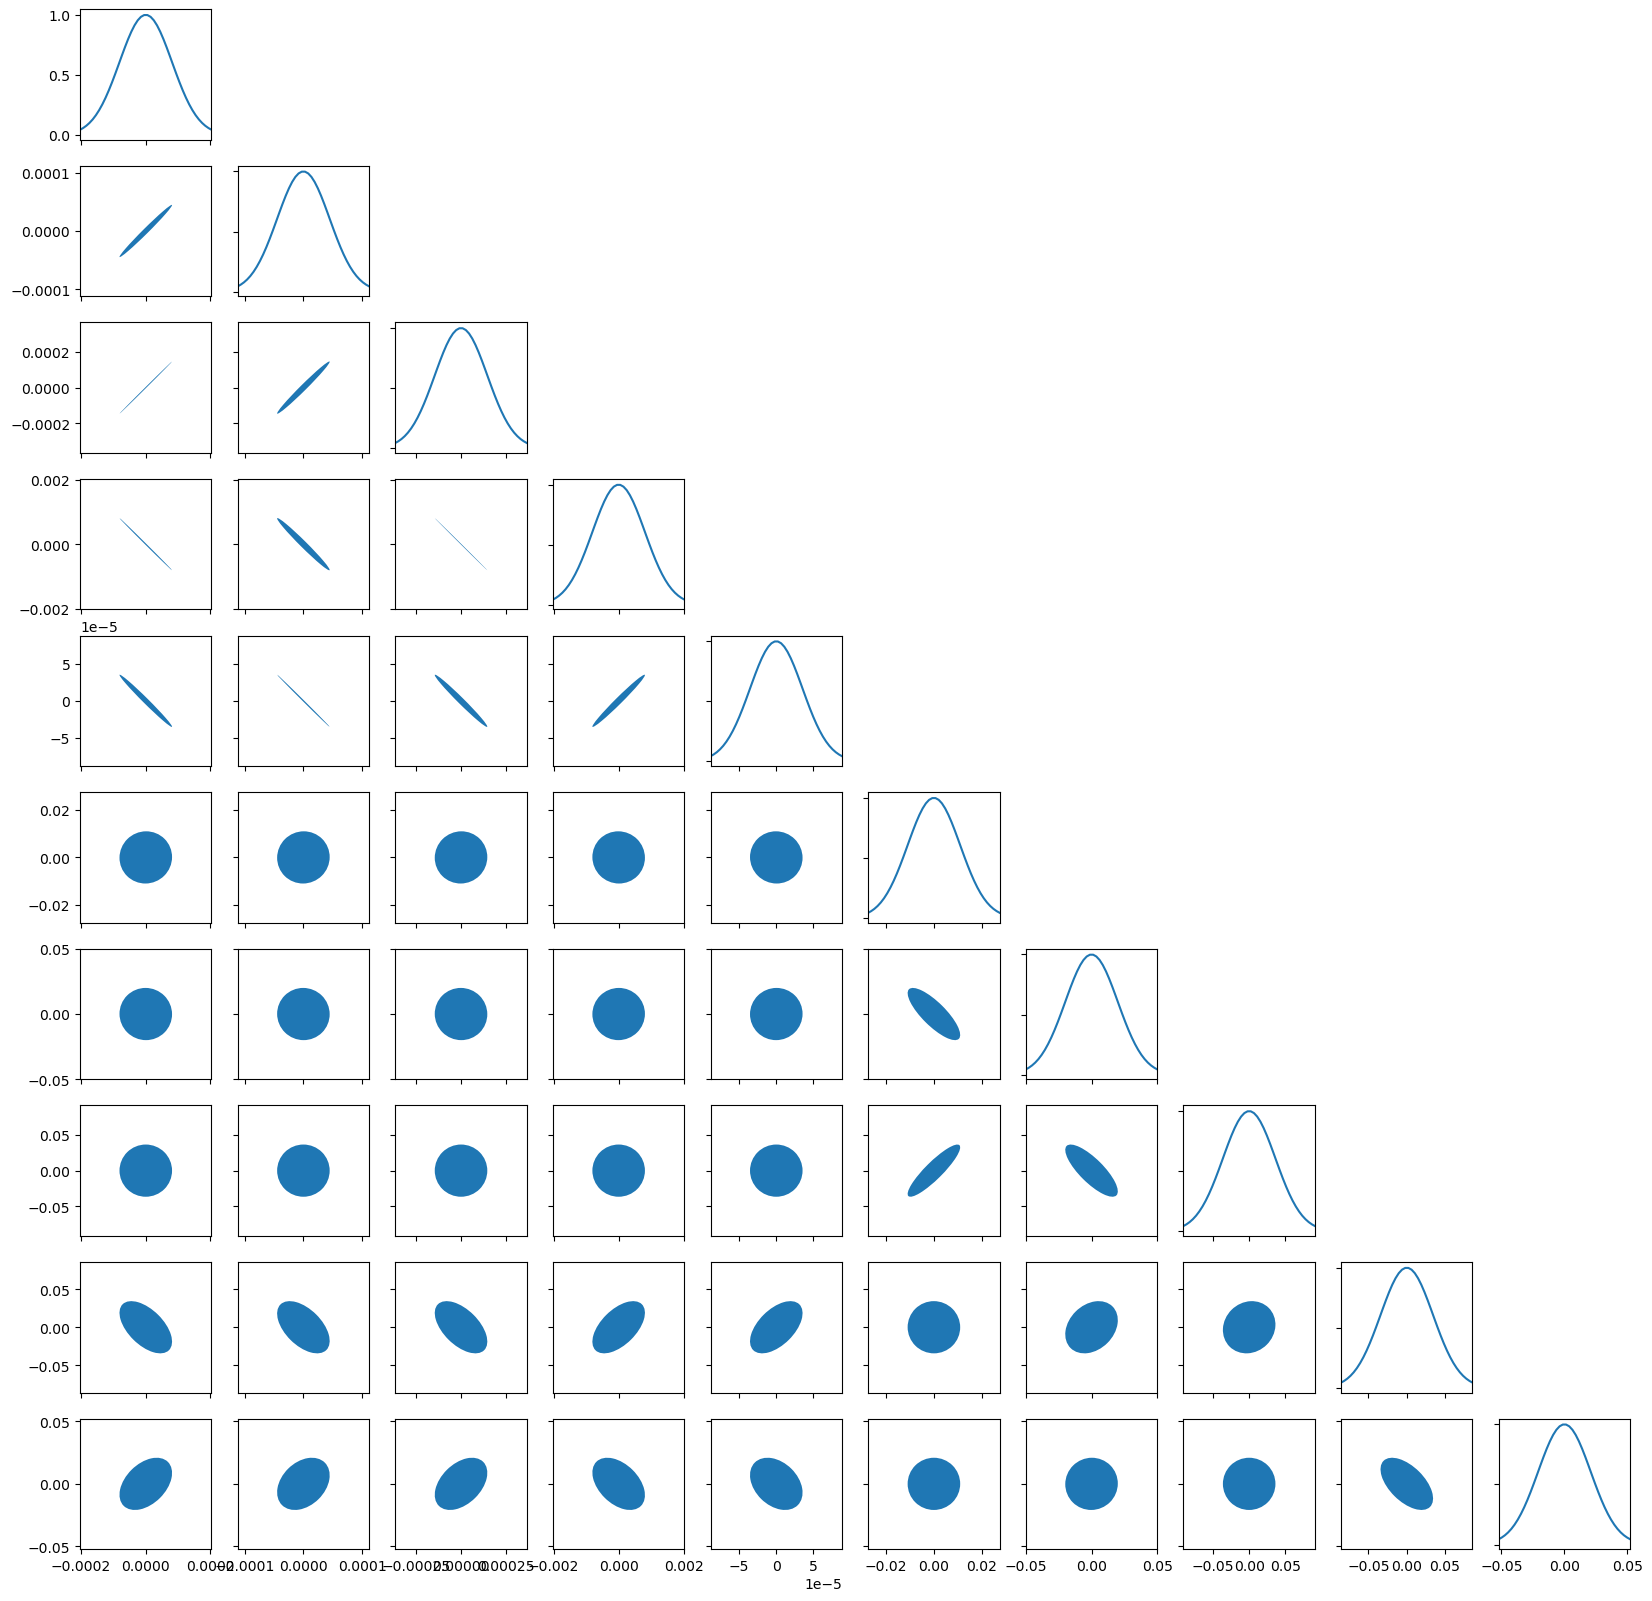

In [16]:
from stableemrifisher.plot import CovEllipsePlot

CovEllipsePlot(np.linalg.inv(Fisher_scaled))

In [17]:
cov = np.linalg.inv(Fisher_scaled)
cov

array([[ 6.61695463e-09,  3.60293879e-09,  1.18258744e-08,
        -6.57747694e-08, -2.84232041e-09,  1.32478263e-08,
        -1.41970506e-08, -1.61055894e-10, -1.53896783e-06,
         7.05159260e-07],
       [ 3.60293879e-09,  2.00117291e-09,  6.42177140e-09,
        -3.56535332e-08, -1.57857274e-09,  7.29060311e-09,
        -7.79541413e-09, -1.56619007e-10, -8.03365906e-07,
         3.03049865e-07],
       [ 1.18258744e-08,  6.42177140e-09,  2.11473711e-08,
        -1.17632656e-07, -5.06384246e-09,  2.36174590e-08,
        -2.57978466e-08, -6.78384677e-10, -2.73308181e-06,
         1.27654857e-06],
       [-6.57747694e-08, -3.56535332e-08, -1.17632656e-07,
         6.54497650e-07,  2.81224120e-08, -1.31281493e-07,
         1.41508423e-07,  2.19008240e-09,  1.53758656e-05,
        -7.30994176e-06],
       [-2.84232041e-09, -1.57857274e-09, -5.06384246e-09,
         2.81224120e-08,  1.24669214e-09, -5.76123674e-09,
         5.91592254e-09, -8.01824406e-11,  6.53336756e-07,
        -2.

In [18]:
np.diag(cov)

array([6.61695463e-09, 2.00117291e-09, 2.11473711e-08, 6.54497650e-07,
       1.24669214e-09, 1.20093803e-04, 4.00603499e-04, 1.32500734e-03,
       1.17646314e-03, 4.34107407e-04])

In [19]:
sigmas = []
for i in range(len(param_names)):
    sigmas.append(1/np.sqrt(Fisher_scaled[i, i]))

In [20]:
sigmas

[1.783697473572608e-08,
 9.936099812795497e-08,
 2.0775752581396848e-07,
 1.8736100146783182e-07,
 7.60974318068818e-08,
 0.00465378355872948,
 0.0024476088591162113,
 0.004821902615184002,
 0.0042380691449203905,
 0.005105397334359951]

In [21]:
params = [np.log10(m1), np.log10(m2), a, p0, e0, dist, qS, phiS, Phi_phi0, Phi_r0]
params_names = ['logm1','logm2','a','p0','e0','dist','qS','phiS','Phi_phi0','Phi_r0']

In [22]:
priors = []
for i in range(len(params)):
    print(f"== Parameter: {params_names[i]}, Sigma: {sigmas[i]}")
    # set 3sig prior range
    prior_min = params[i] - 3*sigmas[i]
    prior_max = params[i] + 3*sigmas[i]
    print(f"3-sigma prior range: [{prior_min}, {prior_max}]")
    priors.append([prior_min, prior_max])

== Parameter: logm1, Sigma: 1.783697473572608e-08
3-sigma prior range: [5.999999946489075, 6.000000053510925]
== Parameter: logm2, Sigma: 9.936099812795497e-08
3-sigma prior range: [1.477120956636668, 1.4771215528026567]
== Parameter: a, Sigma: 2.0775752581396848e-07
3-sigma prior range: [0.6999993767274225, 0.7000006232725774]
== Parameter: p0, Sigma: 1.8736100146783182e-07
3-sigma prior range: [7.499999437916996, 7.500000562083004]
== Parameter: e0, Sigma: 7.60974318068818e-08
3-sigma prior range: [0.3999997717077046, 0.4000002282922954]
== Parameter: dist, Sigma: 0.00465378355872948
3-sigma prior range: [0.4860386493238116, 0.5139613506761884]
== Parameter: qS, Sigma: 0.0024476088591162113
3-sigma prior range: [0.49265717342265136, 0.5073428265773486]
== Parameter: phiS, Sigma: 0.004821902615184002
3-sigma prior range: [0.985534292154448, 1.014465707845552]
== Parameter: Phi_phi0, Sigma: 0.0042380691449203905
3-sigma prior range: [0.3872857925652389, 0.41271420743476117]
== Paramete

In [23]:
# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test')

In [24]:
import pickle
with open('cov_matrix_new.pkl', 'wb') as f:
    pickle.dump(cov, f)

In [2]:
import os
import sys 
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test')

import pickle
with open('cov_matrix_new.pkl', 'rb') as f:
    cov_matrix = pickle.load(f)

In [4]:
import numpy as np
Fisher_scaled = np.linalg.inv(cov_matrix)

In [12]:
mul_F_C = np.asmatrix(np.matmul(Fisher_scaled, cov_matrix))
mul_F_C

matrix([[ 9.99999746e-01, -1.39942322e-07, -4.54790892e-07,
          2.47072436e-06,  1.10917021e-07,  1.48265365e-06,
          2.38288164e-06,  8.88538906e-07,  5.54892852e-05,
         -2.45656600e-05],
        [ 1.71507914e-09,  1.00000000e+00,  2.58273967e-09,
         -4.95581620e-09, -8.27798291e-10, -3.50483167e-07,
         -3.13458072e-07, -1.58076062e-07,  3.34296715e-07,
         -6.56209482e-07],
        [ 2.70139359e-08,  1.46546874e-08,  1.00000005e+00,
         -2.75761686e-07, -1.15776174e-08,  2.16558004e-07,
          6.47132937e-08,  8.65303600e-08, -6.62947338e-06,
          3.29635297e-06],
        [-1.64054478e-08, -9.24408534e-09, -2.94753643e-08,
          1.00000016e+00,  7.09343158e-09,  1.57696829e-07,
          2.06903047e-07,  8.73598378e-08,  3.54884937e-06,
         -1.47552938e-06],
        [-9.20977000e-08, -5.04983476e-08, -1.64744770e-07,
          9.09230773e-07,  1.00000004e+00,  2.71205958e-07,
          6.26938852e-07,  2.10035718e-07,  2.101932

In [14]:
np.sum(np.matrix.sum(mul_F_C, axis=0))

10.00004905814041

In [9]:
params = [np.log10(m1), np.log10(m2), a, p0, e0, dist, np.cos(qS), phiS, Phi_phi0, Phi_r0]
params_names = ['logm1','logm2','a','p0','e0','dist','cosqS','phiS','Phi_phi0','Phi_r0']

In [11]:
sigmas = []
for i in range(len(params_names)):
    sigmas.append(1/np.sqrt(Fisher_scaled[i, i]))

In [12]:
priors = []
for i in range(len(params)):
    print(f"== Parameter: {params_names[i]}, Sigma: {sigmas[i]}")
    # set 3sig prior range
    prior_min = params[i] - 3*sigmas[i]
    prior_max = params[i] + 3*sigmas[i]
    print(f"3-sigma prior range: [{prior_min}, {prior_max}]")
    priors.append([prior_min, prior_max])

== Parameter: logm1, Sigma: 1.7836974796682097e-08
3-sigma prior range: [5.999999946489075, 6.000000053510925]
== Parameter: logm2, Sigma: 9.936099845366556e-08
3-sigma prior range: [1.477120956636667, 1.4771215528026578]
== Parameter: a, Sigma: 2.077575264004321e-07
3-sigma prior range: [0.6999993767274207, 0.7000006232725792]
== Parameter: p0, Sigma: 1.8736100210771288e-07
3-sigma prior range: [7.499999437916994, 7.500000562083006]
== Parameter: e0, Sigma: 7.609743205469199e-08
3-sigma prior range: [0.39999977170770384, 0.4000002282922962]
== Parameter: dist, Sigma: 0.00465378355872948
3-sigma prior range: [0.4860386493238116, 0.5139613506761884]
== Parameter: cosqS, Sigma: 0.002447608864916322
3-sigma prior range: [0.8702397352956238, 0.8849253884851217]
== Parameter: phiS, Sigma: 0.004821902626011084
3-sigma prior range: [0.9855342921219667, 1.0144657078780333]
== Parameter: Phi_phi0, Sigma: 0.004238069155370484
3-sigma prior range: [0.38728579253388856, 0.4127142074661115]
== Para